# SankhyaVox — HMM (GMM-HMM) Classifier Training

Train and evaluate the GMM-HMM baseline on augmented data, test on held-out human speaker.

**Prerequisites:** Run `DataPipeline().build()` and augmentation first.

In [1]:
# ── stdlib ──
import time
import pickle
from pathlib import Path
from typing import Any, Dict, Iterator, List, Optional, Tuple

# ── third-party ──
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

## Config

In [2]:
# ── Paths ──
DATA_PROCESSED = "/kaggle/input/datasets/devarabhavana/sankhyavox-dataset/data_processed"
PROCESSED_DIR  = DATA_PROCESSED          # alias used by SankhyaVoxDataset default
CHECKPOINT_DIR = Path("./checkpoints")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# Human speaker to hold out for testing
TEST_SPEAKER = "S05"

# ── HMM parameters ──
# State count per token — sized to phonetic complexity
HMM_STATES = {
    "shunya":  8,
    "eka":     6,
    "dvi":     6,
    "tri":     6,
    "catur":   9,
    "pancha":  9,
    "shat":    8,
    "sapta":   9,
    "ashta":   9,
    "nava":    8,
    "dasha":   8,
    "vimsati": 12,
    "shata":   8,
}

# Per-token GMM mixtures — more for confused tokens
GMM_MIXTURES = {
    "shunya":  12,
    "eka":     12,
    "dvi":     12,
    "tri":     12,
    "catur":   12,
    "pancha":  12,
    "shat":    12,
    "sapta":   12,
    "ashta":   12,
    "nava":    12,
    "dasha":   12,
    "vimsati": 12,
    "shata":   12,
}

BAUM_WELCH_ITERS   = 200       # EM iterations for training

# Some other config
# ═══════════════════════════════════════════════════════════════════════════════
# VOCABULARY
# The 13 base Sanskrit tokens that compose all numbers 0–99
# ═══════════════════════════════════════════════════════════════════════════════

VOCAB = [
    "shunya",    # 0
    "eka",       # 1
    "dvi",       # 2
    "tri",       # 3
    "catur",     # 4
    "pancha",    # 5
    "shat",      # 6
    "sapta",     # 7
    "ashta",     # 8
    "nava",      # 9
    "dasha",     # 10
    "vimsati",   # 20
    "shata",     # 100
]

TOKEN_TO_IDX = {tok: i for i, tok in enumerate(VOCAB)}
IDX_TO_TOKEN = {i: tok for i, tok in enumerate(VOCAB)}

# ═══════════════════════════════════════════════════════════════════════════════
# NUMERIC ID MAPPING
# Zero-padded 3-digit IDs used in the processed file naming convention:
#   <SpeakerId>_<numericId>_<rep>.wav   e.g. S01_001_03.wav
# ═══════════════════════════════════════════════════════════════════════════════

TOKEN_TO_NUMERIC_ID = {
    "shunya":  "000",
    "eka":     "001",
    "dvi":     "002",
    "tri":     "003",
    "catur":   "004",
    "pancha":  "005",
    "shat":    "006",
    "sapta":   "007",
    "ashta":   "008",
    "nava":    "009",
    "dasha":   "010",
    "vimsati": "020",
    "shata":   "100",
}
NUMERIC_ID_TO_TOKEN = {v: k for k, v in TOKEN_TO_NUMERIC_ID.items()}

# Numeric value each token represents (used as classification labels)
TOKEN_TO_VALUE = {
    "shunya": 0, "eka": 1, "dvi": 2, "tri": 3, "catur": 4,
    "pancha": 5, "shat": 6, "sapta": 7, "ashta": 8, "nava": 9,
    "dasha": 10, "vimsati": 20, "shata": 100,
}
VALUE_TO_TOKEN = {v: k for k, v in TOKEN_TO_VALUE.items()}

## SankhyaVoxDataset

**Paste the `SankhyaVoxDataset` class from `dataset/dataset.py` below.**

In [3]:
class SankhyaVoxDataset:
    """
    Unified dataset for SankhyaVox training and evaluation.

    Reads ``<processed_dir>/human.csv``, ``tts.csv``, ``augmented.csv``
    and concatenates them into a single DataFrame.

    Parameters
    ----------
    processed_dir : Path or str, optional
        Root of the processed data tree.  Default: ``config.PROCESSED_DIR``.
    categories : list of str, optional
        Which categories to load.  Default: all CSVs present on disk.

    ``ds[i]`` returns::

        {
            "audio_path":   str,      # path to source .wav segment
            "audio_source": str,      # "human" | "tts" | "augmented"
            "speaker_id":   str,      # e.g. "S01"
            "token":        str,      # Sanskrit label, e.g. "eka"
            "label":        int,      # numeric value, e.g. 1
            "feature":      ndarray,  # shape (n_frames, 39)
        }
    """

    CATEGORIES = ("human", "tts", "augmented")

    def __init__(
        self,
        processed_dir: Optional[Path] = None,
        categories: Optional[List[str]] = None,
    ):
        self._root = (Path(processed_dir) if processed_dir else PROCESSED_DIR).resolve()
        self._categories = categories or list(self.CATEGORIES)
        self._df = self._load_csvs()

    # ── Loading ───────────────────────────────────────────────────────────

    def _load_csvs(self) -> pd.DataFrame:
        """Load and concatenate category CSV files."""
        frames = []
        for cat in self._categories:
            csv_path = self._root / f"{cat}.csv"
            if csv_path.exists():
                df = pd.read_csv(csv_path)
                df["category"] = cat
                frames.append(df)

        if not frames:
            return pd.DataFrame()

        return pd.concat(frames, ignore_index=True)

    # ── Properties ────────────────────────────────────────────────────────

    @property
    def df(self) -> pd.DataFrame:
        """Full metadata DataFrame."""
        return self._df

    @property
    def speakers(self) -> List[str]:
        """Sorted list of unique speaker IDs."""
        if self._df.empty:
            return []
        return sorted(self._df["speaker"].unique().tolist())

    @property
    def tokens(self) -> List[str]:
        """Sorted list of unique Sanskrit token labels."""
        if self._df.empty:
            return []
        return sorted(self._df["sanskrit_label"].unique().tolist())

    # ── Indexing ──────────────────────────────────────────────────────────

    def __getitem__(self, idx: int) -> Dict[str, Any]:
        """Return a sample dict for the given global index."""
        row = self._df.iloc[idx]
        npy_abs = str(self._root / row["npy_path"])
        wav_abs = str(self._root / row["wav_path"])
        return {
            "audio_path": wav_abs,
            "audio_source": row["category"],
            "speaker_id": row["speaker"],
            "token": row["sanskrit_label"],
            "label": int(row["label"]),
            "feature": np.load(npy_abs),
        }

    def __len__(self) -> int:
        return len(self._df)

    def __iter__(self) -> Iterator[Dict[str, Any]]:
        for i in range(len(self)):
            yield self[i]

    # ── Batch access ──────────────────────────────────────────────────────

    def get_Xy(self) -> Tuple[List[np.ndarray], List[int]]:
        """Return ``(features_list, labels_list)`` for model training."""
        X, y = [], []
        for i in range(len(self)):
            s = self[i]
            X.append(s["feature"])
            y.append(s["label"])
        return X, y

    # ── Filtering / Splitting ─────────────────────────────────────────────

    def filter(
        self,
        category: Optional[str] = None,
        speaker: Optional[str] = None,
        label: Optional[int] = None,
    ) -> "SankhyaVoxDataset":
        """Return a new dataset filtered by the given criteria."""
        mask = pd.Series(True, index=self._df.index)
        if category is not None:
            mask &= self._df["category"] == category
        if speaker is not None:
            mask &= self._df["speaker"] == speaker
        if label is not None:
            mask &= self._df["label"] == label

        filtered = SankhyaVoxDataset.__new__(SankhyaVoxDataset)
        filtered._root = self._root
        filtered._categories = self._categories
        filtered._df = self._df[mask].reset_index(drop=True)
        return filtered

    def exclude_speakers(
        self, speakers_to_exclude: List[str]
    ) -> "SankhyaVoxDataset":
        """Return a new dataset excluding the given speaker IDs."""
        mask = ~self._df["speaker"].isin(speakers_to_exclude)
        ds = SankhyaVoxDataset.__new__(SankhyaVoxDataset)
        ds._root = self._root
        ds._categories = self._categories
        ds._df = self._df[mask].reset_index(drop=True)
        return ds

    def split_by_speakers(
        self,
        train: List[str],
        val: List[str],
        test: List[str],
    ) -> Tuple["SankhyaVoxDataset", "SankhyaVoxDataset", "SankhyaVoxDataset"]:
        """Split dataset into train / val / test by speaker IDs."""

        def _subset(spk_list: List[str]) -> "SankhyaVoxDataset":
            ds = SankhyaVoxDataset.__new__(SankhyaVoxDataset)
            ds._root = self._root
            ds._categories = self._categories
            ds._df = self._df[self._df["speaker"].isin(spk_list)].reset_index(
                drop=True
            )
            return ds

        return _subset(train), _subset(val), _subset(test)

    # ── Display ───────────────────────────────────────────────────────────

    def __repr__(self) -> str:
        cats = self._df["category"].value_counts().to_dict() if len(self._df) else {}
        cat_str = ", ".join(f"{k}={v}" for k, v in sorted(cats.items()))
        return f"SankhyaVoxDataset(samples={len(self)}, {cat_str})"

    def summary(self) -> str:
        """Return a detailed formatted summary of the dataset contents.

        For each category present, prints a table with speakers as columns,
        tokens as rows, and sample counts as cell values plus a Total column.
        Then prints a consolidated table aggregating across all speakers per
        category.
        """
        if self._df.empty:
            return repr(self) + "\n  (no samples loaded)"

        lines = [repr(self)]
        lines.append(f"  Speakers: {', '.join(self.speakers)}")
        lines.append(f"  Tokens:   {', '.join(self.tokens)}")
        lines.append("")

        # Build token display labels: "token (label)"
        token_label_map = (
            self._df[["sanskrit_label", "label"]]
            .drop_duplicates()
            .sort_values("label")
        )
        ordered_tokens = token_label_map["sanskrit_label"].tolist()
        token_display = {
            row.sanskrit_label: f"{row.sanskrit_label} ({row.label})"
            for row in token_label_map.itertuples()
        }

        # ── Per-category detail tables ────────────────────────────────────
        for cat in self.CATEGORIES:
            sub = self._df[self._df["category"] == cat]
            if sub.empty:
                continue

            speakers = sorted(sub["speaker"].unique())
            lines.append(f"  ┌─ {cat.upper()} ({len(sub)} samples, "
                         f"{len(speakers)} speakers) ─────────")

            # Build cross-tab: rows=token, cols=speaker
            ct = pd.crosstab(sub["sanskrit_label"], sub["speaker"])
            # Ensure all tokens and speakers present
            ct = ct.reindex(index=ordered_tokens, columns=speakers, fill_value=0)
            ct["Total"] = ct.sum(axis=1)

            # Format header
            row_label_width = max(len(d) for d in token_display.values()) + 2
            col_width = max(max((len(s) for s in speakers), default=5), 5) + 1
            total_width = max(5, len("Total")) + 1

            header = "  " + "".rjust(row_label_width)
            for sp in speakers:
                header += sp.rjust(col_width)
            header += "Total".rjust(total_width)
            lines.append(header)
            lines.append("  " + "─" * (row_label_width + col_width * len(speakers) + total_width))

            for tok in ordered_tokens:
                display = token_display[tok]
                row_str = "  " + display.rjust(row_label_width)
                for sp in speakers:
                    row_str += str(ct.at[tok, sp]).rjust(col_width)
                row_str += str(ct.at[tok, "Total"]).rjust(total_width)
                lines.append(row_str)

            # Column totals
            lines.append("  " + "─" * (row_label_width + col_width * len(speakers) + total_width))
            totals_row = "  " + "Total".rjust(row_label_width)
            for sp in speakers:
                totals_row += str(int(ct[sp].sum())).rjust(col_width)
            totals_row += str(int(ct["Total"].sum())).rjust(total_width)
            lines.append(totals_row)
            lines.append("")

        # ── Consolidated table across categories ──────────────────────────
        cats_present = [c for c in self.CATEGORIES if c in self._df["category"].values]
        if len(cats_present) > 1:
            lines.append("  ┌─ CONSOLIDATED (all categories) ─────────")

            ct_all = pd.crosstab(self._df["sanskrit_label"], self._df["category"])
            ct_all = ct_all.reindex(index=ordered_tokens, columns=cats_present, fill_value=0)
            ct_all["Total"] = ct_all.sum(axis=1)

            row_label_width = max(len(d) for d in token_display.values()) + 2
            cat_width = max(max((len(c) for c in cats_present), default=9), 9) + 1
            total_width = max(5, len("Total")) + 1

            header = "  " + "".rjust(row_label_width)
            for c in cats_present:
                header += c.rjust(cat_width)
            header += "Total".rjust(total_width)
            lines.append(header)
            lines.append("  " + "─" * (row_label_width + cat_width * len(cats_present) + total_width))

            for tok in ordered_tokens:
                display = token_display[tok]
                row_str = "  " + display.rjust(row_label_width)
                for c in cats_present:
                    row_str += str(ct_all.at[tok, c]).rjust(cat_width)
                row_str += str(ct_all.at[tok, "Total"]).rjust(total_width)
                lines.append(row_str)

            lines.append("  " + "─" * (row_label_width + cat_width * len(cats_present) + total_width))
            totals_row = "  " + "Total".rjust(row_label_width)
            for c in cats_present:
                totals_row += str(int(ct_all[c].sum())).rjust(cat_width)
            totals_row += str(int(ct_all["Total"].sum())).rjust(total_width)
            lines.append(totals_row)
            lines.append("")

        return "\n".join(lines)


## Load Data & Split

In [4]:
# Training: augmented data, excluding held-out speaker
aug_ds = SankhyaVoxDataset(DATA_PROCESSED, categories=["augmented"])
print(f"Full augmented: {repr(aug_ds)}")
print(f"Augmented speakers: {aug_ds.speakers}")

# Exclude the test speaker's augmented variant
aug_test_speaker = f"aug{TEST_SPEAKER}"  # e.g. "augS05"
train_ds = aug_ds.exclude_speakers([aug_test_speaker, "augS04"]) 
X_train, y_train = train_ds.get_Xy()
print(f"\nTrain: {len(X_train)} samples (excluded {aug_test_speaker})")

# Testing: real human recordings for held-out speaker
human_ds = SankhyaVoxDataset(DATA_PROCESSED, categories=["human"])
test_ds = human_ds.filter(speaker=TEST_SPEAKER)
X_test, y_test = test_ds.get_Xy()
print(f"Test:  {len(X_test)} samples (human {TEST_SPEAKER})")
print(f"Labels in test: {sorted(set(y_test))}")
print(f"Feature shape example: {X_train[0].shape}")

print("=" * 70)
print("TRAIN DATA SUMMARY:")
print("=" * 70)
print(train_ds.summary())
print()

print("=" * 70)
print("TEST DATA SUMMARY:")
print("=" * 70)
print(test_ds.summary())
print()

Full augmented: SankhyaVoxDataset(samples=10962, augmented=10962)
Augmented speakers: ['augS01', 'augS02', 'augS03', 'augS04', 'augS05', 'augTTS01', 'augTTS02', 'augTTS03', 'augTTS04']

Train: 8280 samples (excluded augS05)
Test:  171 samples (human S05)
Labels in test: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 100]
Feature shape example: (79, 39)
TRAIN DATA SUMMARY:
SankhyaVoxDataset(samples=8280, augmented=8280)
  Speakers: augS01, augS02, augS03, augTTS01, augTTS02, augTTS03, augTTS04
  Tokens:   ashta, catur, dasha, dvi, eka, nava, pancha, sapta, shat, shata, shunya, tri, vimsati

  ┌─ AUGMENTED (8280 samples, 7 speakers) ─────────
                   augS01   augS02   augS03 augTTS01 augTTS02 augTTS03 augTTS04 Total
  ───────────────────────────────────────────────────────────────────────────────────
      shunya (0)      108       90       90       90       90       90       90   648
         eka (1)      117       90       90       90       90       90       90   657
         dvi (2

---
## HMM Classifier

**Paste the `SankhyaHMM` class from `models/hmm_classifier.py` below.**

In [5]:
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 4.3 MB/s eta 0:00:00


In [6]:
from hmmlearn.hmm import GMMHMM

_DEFAULT_MIX = 2  # fallback when a token is missing from the mix map


class SankhyaHMM:
    """
    HMM baseline: one Bakis GMM-HMM per class, classify by max
    per-frame log-likelihood.

    Parameters
    ----------
    n_iter : int
        EM (Baum-Welch) iterations per model.
    mix_map : dict[str, int], optional
        Token → number of GMM components per state.
        Defaults to ``config.GMM_MIXTURES``.
    states_map : dict[str, int], optional
        Token → number of HMM states.  Defaults to ``config.HMM_STATES``.
    checkpoint_path : str or Path, optional
        If given, load a previously saved model.
    """

    def __init__(
        self,
        n_iter: int = BAUM_WELCH_ITERS,
        mix_map: Optional[dict[str, int]] = None,
        states_map: Optional[dict[str, int]] = None,
        checkpoint_path: Optional[str] = None,
    ):
        self.n_iter = n_iter
        self.mix_map = dict(mix_map or GMM_MIXTURES)
        self.states_map = dict(states_map or HMM_STATES)
        self.models: dict[int, GMMHMM] = {}
        self._label_to_token: dict[int, str] = {}

        if checkpoint_path:
            self.load(checkpoint_path)

    # ── Topology ──────────────────────────────────────────────────────────

    @staticmethod
    def _bakis_transmat(n_states: int) -> np.ndarray:
        A = np.zeros((n_states, n_states))
        for i in range(n_states):
            if i < n_states - 2:
                A[i, i]     = 0.5   # stay
                A[i, i + 1] = 0.35  # advance
                A[i, i + 2] = 0.15  # skip
            elif i < n_states - 1:
                A[i, i]     = 0.6
                A[i, i + 1] = 0.4
            else:
                A[i, i] = 1.0
        return A

    @staticmethod
    def _bakis_startprob(n_states: int) -> np.ndarray:
        pi = np.full(n_states, 1e-10)
        pi[0] = 1.0
        pi /= pi.sum()
        return pi

    # ── Training ──────────────────────────────────────────────────────────

    def _fit_one(self, label: int, sequences: list[np.ndarray]) -> GMMHMM:
        """Fit a single GMM-HMM for one class label."""
        token = VALUE_TO_TOKEN.get(label, str(label))
        n_states = self.states_map.get(token, 5)
        n_mix = self.mix_map.get(token, _DEFAULT_MIX)

        X = np.concatenate(sequences, axis=0)
        lengths = [seq.shape[0] for seq in sequences]

        model = GMMHMM(
            n_components=n_states,
            n_mix=n_mix,
            n_iter=self.n_iter,
            covariance_type="diag",
            verbose=False,
            init_params="mcw",   # skip random init of startprob/transmat
            params="tmcw",        #  was "stmcw": freeze s and t to preserve Bakis
            covars_prior=1e-2,   # variance floor prior
            covars_weight=1.0,   # ADD: prior strength
        )
        model.startprob_ = self._bakis_startprob(n_states)
        model.transmat_ = self._bakis_transmat(n_states)

        model.fit(X, lengths)
        return model

    def fit(self, X: list[np.ndarray], y: list[int]) -> "SankhyaHMM":
        """
        Fit one GMM-HMM per class.

        Parameters
        ----------
        X : list of ndarray, each (n_frames, 39)
        y : list of int labels
        """
        # Group sequences by label
        groups: dict[int, list[np.ndarray]] = {}
        for feat, label in zip(X, y):
            if feat.shape[0] < 3:
                continue
            groups.setdefault(label, []).append(feat)

        for label, seqs in sorted(groups.items()):
            token = VALUE_TO_TOKEN.get(label, str(label))
            self._label_to_token[label] = token
            t0 = time.perf_counter()
            self.models[label] = self._fit_one(label, seqs)
            elapsed = time.perf_counter() - t0
            n_states = self.states_map.get(token, 5)
            n_mix = self.mix_map.get(token, _DEFAULT_MIX)
            model = self.models[label]
            status = f"converged ({model.monitor_.iter} iters)" if model.monitor_.converged else f"no convergence ({model.monitor_.iter} iters)"
            print(
                f"  {token:>8s} (label={label:>3d}): "
                f"{len(seqs):4d} seqs, {n_states} states, "
                f"{n_mix} mix, {elapsed:.1f}s, {status}"
            )

        return self

    # ── Scoring / Prediction ──────────────────────────────────────────────

    def score(self, label: int, mfcc: np.ndarray) -> float:
        """Per-frame log-likelihood of *mfcc* under the model for *label*."""
        if label not in self.models:
            return -1e9
        try:
            return self.models[label].score(mfcc) / mfcc.shape[0]
        except Exception as e:
            # This reveals which models are broken
            print(f"  ⚠ score failed for label={label}: {e}")
            return -1e9

    def predict(self, X: list[np.ndarray]) -> np.ndarray:
        """Predict class labels for a list of MFCC sequences."""
        preds = []
        for feat in X:
            best_label = max(
                self.models, key=lambda l: self.score(l, feat)
            )
            preds.append(best_label)
        return np.array(preds)

    # ── Persistence ───────────────────────────────────────────────────────

    def save(self, path: str) -> None:
        """Save model to a pickle file."""
        Path(path).parent.mkdir(parents=True, exist_ok=True)
        with open(path, "wb") as f:
            pickle.dump(
                {
                    "n_iter": self.n_iter,
                    "mix_map": self.mix_map,
                    "states_map": self.states_map,
                    "models": self.models,
                    "label_to_token": self._label_to_token,
                },
                f,
            )
        print(f"Saved SankhyaHMM -> {path}")

    def load(self, path: str) -> None:
        """Load model from a pickle file."""
        with open(path, "rb") as f:
            data = pickle.load(f)
        self.n_iter = data["n_iter"]
        self.mix_map = data.get("mix_map", data.get("n_mix", GMM_MIXTURES))
        if isinstance(self.mix_map, int):
            self.mix_map = {tok: self.mix_map for tok in VOCAB}
        self.states_map = data["states_map"]
        self.models = data["models"]
        self._label_to_token = data.get("label_to_token", {})
        print(f"Loaded SankhyaHMM <- {path}")


## Train

In [7]:
hmm = SankhyaHMM(n_iter=BAUM_WELCH_ITERS, mix_map=GMM_MIXTURES, states_map=HMM_STATES)
hmm.fit(X_train, y_train)
print("Training complete.")

    shunya (label=  0):  648 seqs, 8 states, 12 mix, 1809.4s, converged (195 iters)
       eka (label=  1):  657 seqs, 6 states, 12 mix, 1453.2s, converged (200 iters)
       dvi (label=  2):  630 seqs, 6 states, 12 mix, 1388.7s, converged (200 iters)
       tri (label=  3):  639 seqs, 6 states, 12 mix, 1267.9s, converged (200 iters)
     catur (label=  4):  630 seqs, 9 states, 12 mix, 1972.0s, converged (191 iters)
    pancha (label=  5):  639 seqs, 9 states, 12 mix, 2099.2s, converged (200 iters)
      shat (label=  6):  585 seqs, 8 states, 12 mix, 1591.4s, converged (195 iters)
     sapta (label=  7):  639 seqs, 9 states, 12 mix, 2116.4s, converged (200 iters)


/usr/local/lib/python3.12/dist-packages/hmmlearn/_emissions.py:208: RuntimeWarning: divide by zero encountered in log
  log_cur_weights = np.log(self.weights_[i_comp])


     ashta (label=  8):  639 seqs, 9 states, 12 mix, 2079.8s, converged (200 iters)
      nava (label=  9):  639 seqs, 8 states, 12 mix, 1629.8s, converged (185 iters)
     dasha (label= 10):  639 seqs, 8 states, 12 mix, 1742.8s, converged (200 iters)
   vimsati (label= 20):  648 seqs, 12 states, 12 mix, 3058.6s, converged (200 iters)
     shata (label=100):  648 seqs, 8 states, 12 mix, 1799.9s, converged (200 iters)
Training complete.


## Save

In [8]:
hmm.save(str(CHECKPOINT_DIR / "hmm_classifier.pkl"))

Saved SankhyaHMM -> checkpoints/hmm_classifier.pkl


## Load

In [9]:
hmm_loaded = SankhyaHMM(checkpoint_path=str(CHECKPOINT_DIR / "hmm_classifier.pkl"))

Loaded SankhyaHMM <- checkpoints/hmm_classifier.pkl


## Test

In [10]:
hmm_preds = hmm_loaded.predict(X_test)
hmm_acc = accuracy_score(y_test, hmm_preds)
print(f"HMM Accuracy: {hmm_acc:.3f}")
print()
print(classification_report(y_test, hmm_preds, zero_division=0))

/usr/local/lib/python3.12/dist-packages/hmmlearn/_emissions.py:208: RuntimeWarning: divide by zero encountered in log
  log_cur_weights = np.log(self.weights_[i_comp])
/usr/local/lib/python3.12/dist-packages/hmmlearn/_emissions.py:208: RuntimeWarning: divide by zero encountered in log
  log_cur_weights = np.log(self.weights_[i_comp])
/usr/local/lib/python3.12/dist-packages/hmmlearn/_emissions.py:208: RuntimeWarning: divide by zero encountered in log
  log_cur_weights = np.log(self.weights_[i_comp])
/usr/local/lib/python3.12/dist-packages/hmmlearn/_emissions.py:208: RuntimeWarning: divide by zero encountered in log
  log_cur_weights = np.log(self.weights_[i_comp])
/usr/local/lib/python3.12/dist-packages/hmmlearn/_emissions.py:208: RuntimeWarning: divide by zero encountered in log
  log_cur_weights = np.log(self.weights_[i_comp])
/usr/local/lib/python3.12/dist-packages/hmmlearn/_emissions.py:208: RuntimeWarning: divide by zero encountered in log
  log_cur_weights = np.log(self.weights_[i

HMM Accuracy: 0.626

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        13
           1       0.20      1.00      0.33        10
           2       1.00      0.60      0.75        10
           3       0.72      0.93      0.81        14
           4       0.94      1.00      0.97        15
           5       1.00      0.67      0.80        12
           6       0.44      1.00      0.61        14
           7       0.00      0.00      0.00        13
           8       1.00      0.27      0.42        15
           9       1.00      1.00      1.00        12
          10       1.00      0.83      0.91        12
          20       1.00      0.12      0.21        17
         100       0.00      0.00      0.00        14

    accuracy                           0.63       171
   macro avg       0.72      0.65      0.60       171
weighted avg       0.72      0.63      0.59       171



/usr/local/lib/python3.12/dist-packages/hmmlearn/_emissions.py:208: RuntimeWarning: divide by zero encountered in log
  log_cur_weights = np.log(self.weights_[i_comp])
/usr/local/lib/python3.12/dist-packages/hmmlearn/_emissions.py:208: RuntimeWarning: divide by zero encountered in log
  log_cur_weights = np.log(self.weights_[i_comp])
/usr/local/lib/python3.12/dist-packages/hmmlearn/_emissions.py:208: RuntimeWarning: divide by zero encountered in log
  log_cur_weights = np.log(self.weights_[i_comp])


## Results

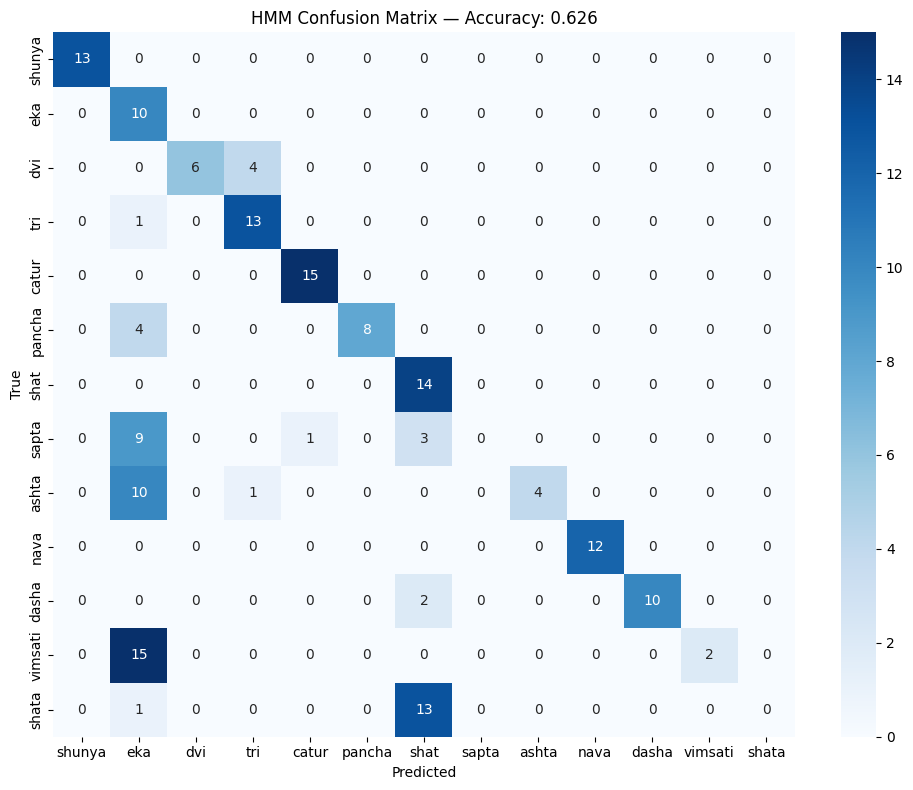


Per-class accuracy:
    shunya (  0): 13/13 = 100.00%
       eka (  1): 10/10 = 100.00%
       dvi (  2): 6/10 = 60.00%
       tri (  3): 13/14 = 92.86%
     catur (  4): 15/15 = 100.00%
    pancha (  5): 8/12 = 66.67%
      shat (  6): 14/14 = 100.00%
     sapta (  7): 0/13 = 0.00%
     ashta (  8): 4/15 = 26.67%
      nava (  9): 12/12 = 100.00%
     dasha ( 10): 10/12 = 83.33%
   vimsati ( 20): 2/17 = 11.76%
     shata (100): 0/14 = 0.00%


In [11]:
# Token label mapping for display
VALUE_TO_TOKEN = {
    0: "shunya", 1: "eka", 2: "dvi", 3: "tri", 4: "catur",
    5: "pancha", 6: "shat", 7: "sapta", 8: "ashta", 9: "nava",
    10: "dasha", 20: "vimsati", 100: "shata",
}

labels_sorted = sorted(set(y_test))
label_names = [VALUE_TO_TOKEN.get(l, str(l)) for l in labels_sorted]

cm = confusion_matrix(y_test, hmm_preds, labels=labels_sorted)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=label_names, yticklabels=label_names)
ax.set_title(f"HMM Confusion Matrix \u2014 Accuracy: {hmm_acc:.3f}")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.tight_layout()
plt.show()

# Per-class accuracy
print("\nPer-class accuracy:")
for i, l in enumerate(labels_sorted):
    row_total = cm[i].sum()
    correct = cm[i, i]
    acc = correct / row_total if row_total > 0 else 0
    print(f"  {VALUE_TO_TOKEN.get(l, str(l)):>8s} ({l:>3d}): {correct}/{row_total} = {acc:.2%}")